In [1]:
# For making a reactive agent it is the loop and reactive_prompt which makes an agent reactive.
# So in-order to make the reactive agents two things needs to be taken care of
# 1. A loop should be there for the task which is supposed to go under iteration.
# 2. Reactive prompt should be there, so that modle should know how to behave exactly in reactive manner.

In [23]:
# Agentic ReAct behavior = LLM instructions/prompt + tool-calling loop + observations fed back into the LLM.

In [2]:
from langsmith import Client
from pathlib import Path

from dotenv import load_dotenv

import langsmith as ls
from rich import print
import os

In [3]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage, AIMessage
from langchain.tools import tool
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.prebuilt import ToolNode, tools_condition


from typing import TypedDict, Literal, Annotated
from typing_extensions import NotRequired

from pydantic import BaseModel, Field

In [4]:
# Load env vars before any LangChain import (tracing caches the client on first import).
project_root = Path.cwd()
if project_root.name == "src":
    project_root = project_root.parent
elif not (project_root / ".env").exists() and (project_root.parent / ".env").exists():
    project_root = project_root.parent

load_dotenv(project_root / ".env", override=True)

# Reset LangSmith's cached tracing client so it picks up the fresh API key.
ls.configure(client=Client())

In [5]:
Client().list_projects(limit=1)

<generator object Client.list_projects at 0x000001B0DFEF8430>

In [6]:
openai_key = os.getenv("OPENAI_KEY")

In [7]:
llm = ChatOpenAI(
    model ="gpt-4.1-mini",
    temperature =0,
    api_key = openai_key
)

In [8]:
@tool
def add(a:float, b:float)->float:
    """ This tool adds two numbers """
    return a+b

@tool
def multiply(a:float, b:float)->float:
    """ This tool multiples two numbers"""
    return a*b

@tool
def divide(a:float, b:float)->float:
    """ This tool divides two number"""
    if(a>b):
        return b/a
    else:
        return a/b

In [9]:
tools = [multiply, add, divide]
llm_with_tools  = llm.bind_tools(tools)

In [10]:
# state

class State(BaseModel):
    messages:Annotated[list[BaseMessage], add_messages]
    user_query:str
    total_calls : int = Field(description="tells how many times llm has been called", default=0)

In [11]:
system_prompt = """
You are a helpful mathematical agent.For every mathematical operation
that requires a tool, use the appropriate tool.

Solve the task by interleaving reasoning and actions.

Thought: [reason about what to do next]
Action: [take an action]
Observation: [observe the result of the action]
Thought: [reason based on the observation]
Action: [take another action if needed]
Observation: [observe the result]
...
Thought: [arrive at the final conclusion]
Answer: [final answer]

"""

In [12]:
def reason_and_respond(state:State):

    if not state.messages:
        messages = [
            SystemMessage(content=system_prompt),
            HumanMessage(content=state.user_query)
        ]
    else:
        messages = state.messages

    response = llm_with_tools.invoke(messages)

    return {
        "messages": [response],
        "total_calls": state.total_calls + 1
    }

In [13]:
tool_node = ToolNode(tools)

In [18]:
# graph 

graph = StateGraph(State)

In [19]:
# adding nodes
graph.add_node("reason_and_respond", reason_and_respond)
graph.add_node("tools", tool_node)

In [20]:
graph.add_edge(START,"reason_and_respond")
graph.add_conditional_edges("reason_and_respond", tools_condition)
graph.add_edge("tools", "reason_and_respond")

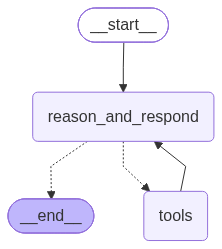

In [21]:
workflow = graph.compile()
workflow

In [22]:
initial_state ={
    "user_query": "what be will 18 added to 76. Multiply the result by 4. Divide it by 3"
}
result = workflow.invoke(initial_state)
print(result)

{
    'messages': [
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 17,
                    'prompt_tokens': 217,
                    'total_tokens': 234,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': 0,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'gpt-4.1-mini-2025-04-14',
                'system_fingerprint': 'fp_c31e0081d1',
                'id': 'chatcmpl-EFDopUgkfKG5Ts9OCR2bbBCM64KBF',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0232f-fc11-7742-9c5d-a15fb50371a5-0',
            tool_calls=[
                {
                    'name': 'add',
                    'args': {'a': 18, 'b': 76},
                    'id': 'call_lRuCQ0gjhpjyHVzHe6ismIQA',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 217,
                'output_tokens': 17,
                'total_tokens': 234,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        ToolMessage(
            content='94.0',
            name='add',
            id='0faff225-10c4-4f15-b760-b86b33ef13be',
            tool_call_id='call_lRuCQ0gjhpjyHVzHe6ismIQA'
        ),
        AIMessage(
            content='The sum of 18 and 76 is 94.',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 13,
                    'prompt_tokens': 115,
                    'total_tokens': 128,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': 0,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'gpt-4.1-mini-2025-04-14',
                'system_fingerprint': 'fp_bcb4333501',
                'id': 'chatcmpl-EFDorogXBKb8iL8o2tyA8ZgJRQ37N',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a02330-09ac-7983-bdb1-109a1d1f3d12-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 115,
                'output_tokens': 13,
                'total_tokens': 128,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        )
    ],
    'user_query': 'what be will 18 added to 76. Multiply the result by 4. Divide it by 3',
    'tota